# Normative Path Validation Analysis

**Purpose**: Evaluate the hypothesis that CONTINUATION (not reincarnation) is the normative path.

**Research Question**: Does NDE evidence support a framework where:
1. Soul continuation in the spiritual world is the **normative path** (one life → eternal development)
2. Return to earthly life (via reincarnation or NDE return) is the **exception**
3. Identity and memory persist through the transition

## Theoretical Framework: The Threefold Path

| Path | Description | Frequency | Key Markers |
|------|-------------|-----------|-------------|
| **1. Normative Linear Progression** | Single life → World of Spirits → eternal continuation | Default (most souls) | Absence of past-life recall; complete "seed-state" life |
| **2. Restorative Incarnation** | Return for souls whose development was traumatically interrupted | Exception | Birthmarks, phobias related to death mode, DOPS-verified cases |
| **3. Volunteer Soul Incarnation** | Mission-based return by souls who chose to serve | Rare exception | Pre-birth "choice" memories, NDE "commissioning" moments |

## The 4-Stage Normative Journey

| Stage | NDE Phenomenology | Purpose (Swedenborgian) |
|-------|-------------------|------------------------|
| **1. Passage** | OBE, tunnel, light, peace | Consciousness withdrawing; managed awakening |
| **2. Arrival** | Being of Light, deceased reunions, "home" feeling | World of Spirits; acclimation |
| **3. Self-Revelation** | Life Review | Ruling love made manifest |
| **4. Integration** | Value shifts, purpose | Eternal "use" |

**What NDE data can and cannot test.** Every person in the dataset returned, and the data are retrospective self-reports. The analyses below therefore *describe* return, encounter, identity and review phenomenology and check whether they are **consistent** with the framework. Several markers are not tests in the strict sense (no competing model predicts a different value); this is stated for each.

---
**Notebook**: `02_normative_path_validation.ipynb` · **Schema**: 2026-01-06 · **Audited and corrected**: 2026-10-05

## Audit corrections (2026-10-05)

| # | Problem in previous version | Effect | Fix |
|---|---|---|---|
| 1 | Agency × willingness patterns compared against `'EXTERNAL'`, `'WILLING'`, `'SELF'` (upper case; schema is lower case) | Pattern section printed nothing | Schema values |
| 2 | Printed "Agency and Willingness are **independent**" when p < 0.05 (inverted f-string) | Wrong conclusion | Fixed; χ² recomputed without `not_mentioned` |
| 3 | Return-reason categories `CHILDREN_NEED`, `SENT_BACK`, … do not exist | "0.0% of reasons are not personal preference", followed by the opposite conclusion | Removed; the schema has no "personal preference" reason |
| 4 | Death-fear and spirituality scales used upper-case values (`NONE`, `EXTREME`) | "Insufficient data", yet "Death fear DECREASES significantly" was printed (hard-coded) | Correct scales and Wilcoxon tests |
| 5 | `perspective_of_others`, `pre_incarnation_covenant`, `chose_*`, `mission_commissioned` counted `'yes'` instead of `'yes_explicit'` | Empathetic review 0%; covenant 0.7% (true 1.3%); mission commissioned 0% (true 21.9%) | Schema values |
| 6 | Evidence summary: "support" thresholds chosen so that any plausible value passes (e.g. past-life memory < 10% ⇒ ✓) | "5/5 markers" was not a test | Replaced by an explicit assessment of what each marker can show |
| 7 | "Sequential ordering generally maintained" printed without analysis | Unsupported | Sequence fields analysed (Part VI) |
| 8 | Source tagged by file name substring `'nderf'`, which also matches "wo**nderf**ul" | 4 IANDS records labelled NDERF | Uses the `dataset` field |

## Setup

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092


---
# PART I: Return patterns

In [2]:
print("1. RETURN AGENCY (who decided?)")
agency = df["return_agency"].value_counts()
known = df[df["return_agency"] != "not_mentioned"]
for k, v in agency.items():
    base = f"{nd.fmt_pct(int(v), len(known))} of stated" if k != "not_mentioned" else ""
    print(f"  {k:15s} {v:5d}  {base}")
ext_inv = int(known["return_agency"].isin(["external_being", "involuntary"]).sum())
print(f"\n  Not self-chosen (external_being + involuntary): {nd.fmt_pct(ext_inv, len(known))}")
print(f"  Sent back by a being (external_being only):     {nd.fmt_pct(int((known.return_agency=='external_being').sum()), len(known))}")

print("\n2. RETURN WILLINGNESS (how did they feel?)")
wk = df[df["return_willingness"] != "not_mentioned"]
for k, v in df["return_willingness"].value_counts().items():
    base = f"{nd.fmt_pct(int(v), len(wk))} of stated" if k != "not_mentioned" else ""
    print(f"  {k:15s} {v:5d}  {base}")

1. RETURN AGENCY (who decided?)
  not_mentioned    1970  
  external_being   1930  1930/4781 = 40.4% [95% CI 39.0–41.8] of stated
  involuntary      1422  1422/4781 = 29.7% [95% CI 28.5–31.1] of stated
  self             1124  1124/4781 = 23.5% [95% CI 22.3–24.7] of stated
  mutual            305  305/4781 = 6.4% [95% CI 5.7–7.1] of stated

  Not self-chosen (external_being + involuntary): 3352/4781 = 70.1% [95% CI 68.8–71.4]
  Sent back by a being (external_being only):     1930/4781 = 40.4% [95% CI 39.0–41.8]

2. RETURN WILLINGNESS (how did they feel?)
  not_mentioned    3188  
  reluctant        1759  1759/3563 = 49.4% [95% CI 47.7–51.0] of stated
  mixed             944  944/3563 = 26.5% [95% CI 25.1–28.0] of stated
  willing           763  763/3563 = 21.4% [95% CI 20.1–22.8] of stated
  neutral            97  97/3563 = 2.7% [95% CI 2.2–3.3] of stated


In [3]:
print("3. AGENCY × WILLINGNESS (both stated)")
both = df[(df["return_agency"] != "not_mentioned") & (df["return_willingness"] != "not_mentioned")]
t = pd.crosstab(both["return_agency"], both["return_willingness"])
print(t.to_string())
print("\nRow percentages:")
print((100 * t.div(t.sum(axis=1), axis=0)).round(1).to_string())
chi2, p, dof, _ = chi2_contingency(t)
print(f"\nχ² = {chi2:.1f}, df = {dof}, p = {p:.2g}, Cramér's V = {nd.cramers_v(t):.3f}, n = {len(both)}  ({nd.expected_count_report(t)})")
print("→ Agency and willingness are NOT independent.")
full = pd.crosstab(df["return_agency"], df["return_willingness"])
print(f"(The previously reported χ² = 4,824.8 included the 'not_mentioned' rows/columns, which mostly measures co-missingness: "
      f"{int(full.loc['not_mentioned','not_mentioned'])} records lack both.)")

eb = t.loc["external_being"]; sf = t.loc["self"]
print(f"\nSent back by a being: reluctant {nd.fmt_pct(int(eb['reluctant']), int(eb.sum()))}; willing {nd.fmt_pct(int(eb['willing']), int(eb.sum()))}")
print(f"Chose to return:      willing {nd.fmt_pct(int(sf['willing']), int(sf.sum()))}; reluctant {nd.fmt_pct(int(sf['reluctant']), int(sf.sum()))}")

3. AGENCY × WILLINGNESS (both stated)
return_willingness  mixed  neutral  reluctant  willing
return_agency                                         
external_being        242       43       1006       82
involuntary           143       33        421       20
mutual                111        3         87       92
self                  369       12        109      557

Row percentages:
return_willingness  mixed  neutral  reluctant  willing
return_agency                                         
external_being       17.6      3.1       73.3      6.0
involuntary          23.2      5.3       68.2      3.2
mutual               37.9      1.0       29.7     31.4
self                 35.2      1.1       10.4     53.2

χ² = 1389.0, df = 9, p = 1.9e-293, Cramér's V = 0.373, n = 3330  (min expected = 8.01; cells with expected < 5: 0%)
→ Agency and willingness are NOT independent.
(The previously reported χ² = 4,824.8 included the 'not_mentioned' rows/columns, which mostly measures co-missingness: 17

In [4]:
print("4. RETURN REASONS (multi-select; % of all NDEs)")
for r in nd.allowed_values("return_reasons"):
    print(f"  {r:22s} {nd.fmt_pct(int(nd.has(df, 'return_reasons', r).sum()), N)}")
n_any = int((df["return_reasons"].apply(len) > 0).sum())
print(f"  At least one reason: {nd.fmt_pct(n_any, N)}; more than one: {int((df['return_reasons'].apply(len) > 1).sum())}")
print("\nNOTE: the schema's reason categories (mission, family, not-your-time, unfinished business, other) contain no")
print("'personal preference' category, so 'reasons are duty rather than preference' cannot be tested from this field.")
print(f"Self-chosen AND willing returns: {int(((df.return_agency=='self') & (df.return_willingness=='willing')).sum())}")

4. RETURN REASONS (multi-select; % of all NDEs)
  earthly_mission        623/6751 = 9.2% [95% CI 8.6–9.9]
  family_responsibility  1164/6751 = 17.2% [95% CI 16.4–18.2]
  not_your_time          1459/6751 = 21.6% [95% CI 20.6–22.6]
  unfinished_business    711/6751 = 10.5% [95% CI 9.8–11.3]
  other                  218/6751 = 3.2% [95% CI 2.8–3.7]
  At least one reason: 2988/6751 = 44.3% [95% CI 43.1–45.4]; more than one: 1034

NOTE: the schema's reason categories (mission, family, not-your-time, unfinished business, other) contain no
'personal preference' category, so 'reasons are duty rather than preference' cannot be tested from this field.
Self-chosen AND willing returns: 557


**Findings.**
- *Statistically supported:* among accounts that state who decided, 70.1% did not return by their own choice (40.4% sent back by a being, 29.7% involuntary). Among those stating their attitude, 49.4% were reluctant and 21.4% willing.
- Agency and willingness are strongly associated (Cramér's V ≈ 0.37): being sent back goes with reluctance (73%), choosing to return with willingness (53%).
- *Interpretation:* reluctance shows that experiencers *valued* the NDE state. It is consistent with the framework's claim that the spiritual state is preferable, but it is also what any intensely pleasant altered state would produce; it does not discriminate between models. "Return as exception" is not testable here because every member of the dataset returned.

---
# PART II: Deceased relatives

In [5]:
dec = df["deceased_relatives"]
print("deceased_relatives:", dec.value_counts().to_dict())
yes = int(dec.isin(nd.DECEASED_YES).sum())
print(f"Encountered deceased relatives: {nd.fmt_pct(yes, N)} of all NDEs; {nd.fmt_pct(yes, int((dec != 'not_mentioned').sum()))} of accounts that address it")
print("\nOther souls presence:", df["other_souls_presence"].value_counts().to_dict())
print("Spiritual beings:", Counter(b for bs in df["spiritual_beings"] for b in bs))

deceased_relatives: {'no': 4127, 'not_mentioned': 1418, 'named': 1007, 'unnamed': 199}
Encountered deceased relatives: 1206/6751 = 17.9% [95% CI 17.0–18.8] of all NDEs; 1206/5333 = 22.6% [95% CI 21.5–23.8] of accounts that address it

Other souls presence: {'not_mentioned': 4728, 'many': 962, 'few': 659, 'none': 402}
Spiritual beings: Counter({'unidentified_benevolent': 1733, 'religious_figures': 639, 'guides_or_angels': 558})


**Finding:** 17.9% of NDEs (22.6% of those that address the question) include deceased relatives.

**Interpretation (framework-dependent, not a test):** the framework reads these encounters as evidence that the relatives *continued* rather than reincarnated. The data cannot discriminate this from alternatives: several reincarnation doctrines also allow encounters with the recently dead (e.g. intermediate-state teachings), and there is no measurement of how long the relatives had been dead or whether they "should" have reincarnated. This marker is **consistent with** but does not **test** the continuation hypothesis.

---
# PART III: Identity, memory, and life review

In [6]:
ic = df["identity_continuity"]
stated = ic[ic != "not_mentioned"]
print("identity_continuity:", ic.value_counts().to_dict())
print(f"Clear identity among stated: {nd.fmt_pct(int((stated=='clear_identity').sum()), len(stated))}")

pm = df["premortal_existence_info"]
print(f"\nPremortal existence information: {nd.fmt_pct(int(pm.isin(nd.YES).sum()), N)}")
print("soul_age_characterization:", df["soul_age_characterization"].value_counts().to_dict())

identity_continuity: {'clear_identity': 4376, 'not_mentioned': 2240, 'identity_altered_or_lost': 92, 'identity_confusion': 43}
Clear identity among stated: 4376/4511 = 97.0% [95% CI 96.5–97.5]

Premortal existence information: 478/6751 = 7.1% [95% CI 6.5–7.7]
soul_age_characterization: {'not_mentioned': 6739, 'old_soul': 12}


In [7]:
lr = df[df["life_review"]]
print("LIFE REVIEW OCCURRENCE:", df["occurrence"].value_counts().to_dict())
print(f"  Occurred: {nd.fmt_pct(len(lr), N)}  ({nd.fmt_pct(len(lr), int((df.occurrence!='not_mentioned').sum()))} of accounts that address it)")

print("\nJudgment source WITHIN life reviews (classifiable = not 'not_mentioned'):")
cls = lr[lr["judgment_source"] != "not_mentioned"]
for k, v in cls["judgment_source"].value_counts().items():
    print(f"  {k:18s} {nd.fmt_pct(int(v), len(cls))}")

print("\nJudgment intensity WITHIN life reviews (rated only):")
rated = lr[lr["judgment_intensity"].isin(["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"])]
for k in ["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"]:
    print(f"  {k:18s} {nd.fmt_pct(int((rated.judgment_intensity==k).sum()), len(rated))}")
L = int((rated.judgment_intensity == "loving_gentle").sum()); H = int((rated.judgment_intensity == "harsh_condemning").sum())
U = int((rated.judgment_intensity == "uncomfortable").sum())
ci = stats.binomtest(L, L + H).proportion_ci(method="exact")
print(f"  loving : harsh = {L/H:.1f} : 1 (95% CI {ci.low/(1-ci.low):.1f}–{ci.high/(1-ci.high):.1f});  loving : (uncomfortable + harsh) = {L/(U+H):.2f} : 1")

outside = df[~df["life_review"]]
print(f"\nNOTE: judgment fields are also filled for {int((outside.judgment_intensity.isin(['loving_gentle','neutral','uncomfortable','harsh_condemning'])).sum())} records WITHOUT a life review "
      f"(e.g. judgment in a hellish NDE): harsh = {int((outside.judgment_intensity=='harsh_condemning').sum())}. "
      f"The previously reported 15.9:1 (223:14) mixed both groups.")

print("\nEmpathetic perspective (felt others' emotions) WITHIN life reviews:",
      nd.fmt_pct(int(nd.isin(lr, "perspective_of_others", nd.YES).sum()), len(lr)))
print("Experiencer emotional tone WITHIN life reviews:", lr["life_review_emotional_tone"].value_counts().to_dict())

LIFE REVIEW OCCURRENCE: {'no': 5243, 'brief': 718, 'extensive': 465, 'not_mentioned': 325}
  Occurred: 1183/6751 = 17.5% [95% CI 16.6–18.4]  (1183/6426 = 18.4% [95% CI 17.5–19.4] of accounts that address it)

Judgment source WITHIN life reviews (classifiable = not 'not_mentioned'):


  none               493/928 = 53.1% [95% CI 49.9–56.3]
  guide_or_entity    185/928 = 19.9% [95% CI 17.5–22.6]
  being_of_light     148/928 = 15.9% [95% CI 13.7–18.4]
  self               95/928 = 10.2% [95% CI 8.4–12.4]
  deceased_relative  7/928 = 0.8% [95% CI 0.4–1.5]

Judgment intensity WITHIN life reviews (rated only):
  loving_gentle      217/428 = 50.7% [95% CI 46.0–55.4]
  neutral            85/428 = 19.9% [95% CI 16.4–23.9]
  uncomfortable      120/428 = 28.0% [95% CI 24.0–32.5]
  harsh_condemning   6/428 = 1.4% [95% CI 0.6–3.0]
  loving : harsh = 36.2 : 1 (95% CI 16.3–99.6);  loving : (uncomfortable + harsh) = 1.72 : 1

NOTE: judgment fields are also filled for 26 records WITHOUT a life review (e.g. judgment in a hellish NDE): harsh = 8. The previously reported 15.9:1 (223:14) mixed both groups.

Empathetic perspective (felt others' emotions) WITHIN life reviews: 213/1183 = 18.0% [95% CI 15.9–20.3]
Experiencer emotional tone WITHIN life reviews: {'not_specified': 495, 'mixed

**Findings.**
- *Statistically supported:* where identity is described, it is clear in 97.0% of accounts.
- Life reviews occur in 17.5% of NDEs. Within them, **about a third of classifiable reviews involve an external evaluator** (Being, guide or relative) and two-thirds none or self. Of rated evaluations, about half are loving/gentle, **28% uncomfortable**, and 1.4% harsh. Loving:harsh ≈ 36:1, but loving:critical is only ≈1.7:1 — the review is predominantly *non-condemning*, not uniformly *loving*.
- Empathetic perspective-taking is reported in 18.0% of life reviews (previously printed as 0 because of an enum bug).
- Experiencers' own emotional tone is mostly mixed; love and shame/regret are about equally common.

---
# PART IV: Reincarnation indicators

In [8]:
rows = []
for field in ["past_life_memory", "intermission_memory", "pre_incarnation_covenant", "chose_parents", "chose_mission",
              "chose_life_circumstances", "premortal_existence_info", "pre_birth_realm_description"]:
    v = df[field]
    k = int(v.isin(nd.YES).sum()); stated_n = int((v != "not_mentioned").sum())
    lo, hi = nd.wilson_ci(k, N)
    rows.append({"indicator": field, "yes (explicit+implied)": k, "% of all": round(100*k/N, 1), "95% CI": f"{100*lo:.1f}–{100*hi:.1f}",
                 "% of accounts addressing it": round(100*k/stated_n, 1) if stated_n else np.nan})
print(pd.DataFrame(rows).to_string(index=False))
print("\ndeath_memory:", df["death_memory"].value_counts().to_dict())
print("incarnation_history:", df["incarnation_history"].value_counts().to_dict())

                  indicator  yes (explicit+implied)  % of all  95% CI  % of accounts addressing it
           past_life_memory                     297       4.4 3.9–4.9                          6.2
        intermission_memory                      69       1.0 0.8–1.3                          1.6
   pre_incarnation_covenant                      86       1.3 1.0–1.6                          1.9
              chose_parents                      29       0.4 0.3–0.6                          0.6
              chose_mission                     140       2.1 1.8–2.4                          3.0
   chose_life_circumstances                      82       1.2 1.0–1.5                          1.8
   premortal_existence_info                     478       7.1 6.5–7.7                          9.5
pre_birth_realm_description                     120       1.8 1.5–2.1                          2.6

death_memory: {'not_mentioned': 6701, 'violent': 19, 'unspecified': 15, 'none': 14, 'natural': 2}
incarnatio

**Findings:** past-life memory is reported in 4.4% of NDEs, intermission memory in 1.0%, pre-incarnation covenant in 1.3%, choosing one's mission in 2.1%. Previously printed values for covenant (0.7%), chose-mission (1.4%) and chose-parents (0.1%) were undercounts caused by matching `'yes'`.

**What this can show:** reincarnation content is *rarely reported in NDEs*. It does not show that most people are on a single-life path — absence of a report during a brief NDE is not evidence of absence of prior lives, and no competing model predicts a specific higher rate. The previous "✓ if < 10%" rule guaranteed support. This marker is **consistent with** the framework but **not a test** of it.

---
# PART V: Transformation (before/after, both levels stated)

In [9]:
def pre_post(before, after, scale, label):
    m = df[before].isin(scale) & df[after].isin(scale)
    x, y = df.loc[m, before].map(scale), df.loc[m, after].map(scale)
    w = wilcoxon(x, y)
    print(f"{label}: n = {int(m.sum())}; mean {x.mean():.2f} → {y.mean():.2f}; down {nd.fmt_pct(int((y<x).sum()), int(m.sum()))}; "
          f"up {nd.fmt_pct(int((y>x).sum()), int(m.sum()))}; Wilcoxon W = {w.statistic:.0f}, p = {w.pvalue:.2g}")
    return x, y

fear_x, fear_y = pre_post("death_fear_before", "death_fear_after", nd.FEAR_SCALE, "Death fear (0 none – 4 severe)")
spi_x, spi_y = pre_post("spirituality_before", "spirituality_after", nd.SPIRITUALITY_SCALE, "Spirituality (0 none – 4 central)")
rel_x, rel_y = pre_post("religiosity_before", "religiosity_after", nd.RELIGIOSITY_SCALE, "Religiosity (0 none – 4 devout)")
print(f"\nSelection check: death_fear_after stated for {int((df.death_fear_after!='not_mentioned').sum())}, "
      f"before stated for {int((df.death_fear_before!='not_mentioned').sum())}; both for {len(fear_x)}.")

Death fear (0 none – 4 severe): n = 327; mean 2.43 → 0.31; down 277/327 = 84.7% [95% CI 80.4–88.2]; up 13/327 = 4.0% [95% CI 2.3–6.7]; Wilcoxon W = 1148, p = 4.9e-46
Spirituality (0 none – 4 central): n = 723; mean 1.57 → 2.98; down 12/723 = 1.7% [95% CI 1.0–2.9]; up 605/723 = 83.7% [95% CI 80.8–86.2]; Wilcoxon W = 2198, p = 4e-102
Religiosity (0 none – 4 devout): n = 1168; mean 1.18 → 1.20; down 233/1168 = 19.9% [95% CI 17.8–22.3]; up 236/1168 = 20.2% [95% CI 18.0–22.6]; Wilcoxon W = 53538, p = 0.58

Selection check: death_fear_after stated for 1402, before stated for 569; both for 327.


**Findings (statistically supported, with a selection caveat):** where both levels are stated, death fear falls (85% decrease, 4% increase) and spirituality rises (84% increase), while institutional religiosity shows no net change. "Before" levels are mentioned mainly when they changed, so these percentages describe the reporting subset, not all experiencers.

---
# PART VI: Sequential structure

The 4-stage journey implies an ordering. The schema records how closely each account follows the canonical stage order (`canonical_sequence`: strict / mostly / partial / radical), and whether stages repeated or occurred simultaneously.

In [10]:
cs = df["canonical_sequence"]
assess = cs[cs.isin(["strict", "mostly", "partial", "radical"])]
print("canonical_sequence:", cs.value_counts().to_dict())
for k in ["strict", "mostly", "partial", "radical"]:
    print(f"  {k:8s} {nd.fmt_pct(int((assess==k).sum()), len(assess))} of assessable")
print(f"  strict or mostly: {nd.fmt_pct(int(assess.isin(['strict','mostly']).sum()), len(assess))}")
for f in ["repeated_stages", "simultaneous_stages"]:
    v = df[f]; s_ = v[v != "not_mentioned"]
    print(f"{f}: yes {nd.fmt_pct(int((s_=='yes').sum()), len(s_))} of stated")
print("\nStage elements present (% of NDEs):")
for k, v in Counter(e for es in df["present_elements"] for e in es).most_common():
    print(f"  {k:16s} {100*v/N:.1f}%")

canonical_sequence: {'partial': 3396, 'mostly': 2356, 'radical': 494, 'indeterminate': 272, 'not_applicable': 230, 'strict': 3}
  strict   3/6249 = 0.0% [95% CI 0.0–0.1] of assessable
  mostly   2356/6249 = 37.7% [95% CI 36.5–38.9] of assessable
  partial  3396/6249 = 54.3% [95% CI 53.1–55.6] of assessable
  radical  494/6249 = 7.9% [95% CI 7.3–8.6] of assessable
  strict or mostly: 2359/6249 = 37.8% [95% CI 36.6–39.0]
repeated_stages: yes 862/3727 = 23.1% [95% CI 21.8–24.5] of stated
simultaneous_stages: yes 840/1919 = 43.8% [95% CI 41.6–46.0] of stated

Stage elements present (% of NDEs):


  return_choice    83.5%
  obe              65.6%
  environment      56.8%
  light_encounter  55.8%
  communication    54.9%
  boundary         40.6%
  tunnel           32.9%
  other            23.7%
  loved_ones       21.4%
  life_review      15.2%


**Finding:** strict adherence to the canonical order is essentially absent (3 of 6,249 assessable accounts); 37.7% follow it "mostly", 54.3% "partially", 7.9% depart radically. Stages are frequently repeated or simultaneous. The previous claim "sequential ordering generally maintained" is **not supported**: NDE elements recur in a recognisable *set*, but not in a fixed *sequence*. Whether this is a miss for the framework depends on whether the 4-stage journey is read as a strict temporal order (miss) or as a set of functional phases (underdetermined).

---
# PART VII: Evidence assessment

In [11]:
summary = pd.DataFrame([
    ["Return not self-chosen", f"{100*ext_inv/len(known):.1f}% of stated", "Descriptive; everyone returned, so 'return as exception' is untestable", "Consistent, not a test"],
    ["Reluctance to return", f"{100*(wk.return_willingness=='reluctant').mean():.1f}% of stated", "Shows the state was valued; not model-discriminating", "Consistent, not a test"],
    ["Deceased relatives present", f"{100*yes/N:.1f}% of NDEs", "No competing quantitative prediction", "Consistent, not a test"],
    ["Identity preserved", f"{100*(stated=='clear_identity').mean():.1f}% of stated", "Strong, but also predicted by most survival and non-survival models of NDE phenomenology", "Consistent"],
    ["Past-life memory rare", f"{100*df.past_life_memory.isin(nd.YES).mean():.1f}%", "Absence of report ≠ absence of prior life", "Consistent, not a test"],
    ["Life review non-condemning", f"harsh {100*H/len(rated):.1f}%, uncomfortable {100*U/len(rated):.1f}% of rated", "Framework predicts revelation, not condemnation", "Supported (harsh rare); 'loving' overstated"],
    ["Canonical sequence", f"strict {100*(assess=='strict').mean():.2f}%, mostly {100*(assess=='mostly').mean():.1f}%", "Fixed order not observed", "Not supported as a strict sequence"],
], columns=["Marker", "Value", "What it can show", "Assessment"])
print(summary.to_string(index=False))

                    Marker                                    Value                                                                         What it can show                                  Assessment
    Return not self-chosen                          70.1% of stated                   Descriptive; everyone returned, so 'return as exception' is untestable                      Consistent, not a test
      Reluctance to return                          49.4% of stated                                     Shows the state was valued; not model-discriminating                      Consistent, not a test
Deceased relatives present                            17.9% of NDEs                                                     No competing quantitative prediction                      Consistent, not a test
        Identity preserved                          97.0% of stated Strong, but also predicted by most survival and non-survival models of NDE phenomenology                                  Consis

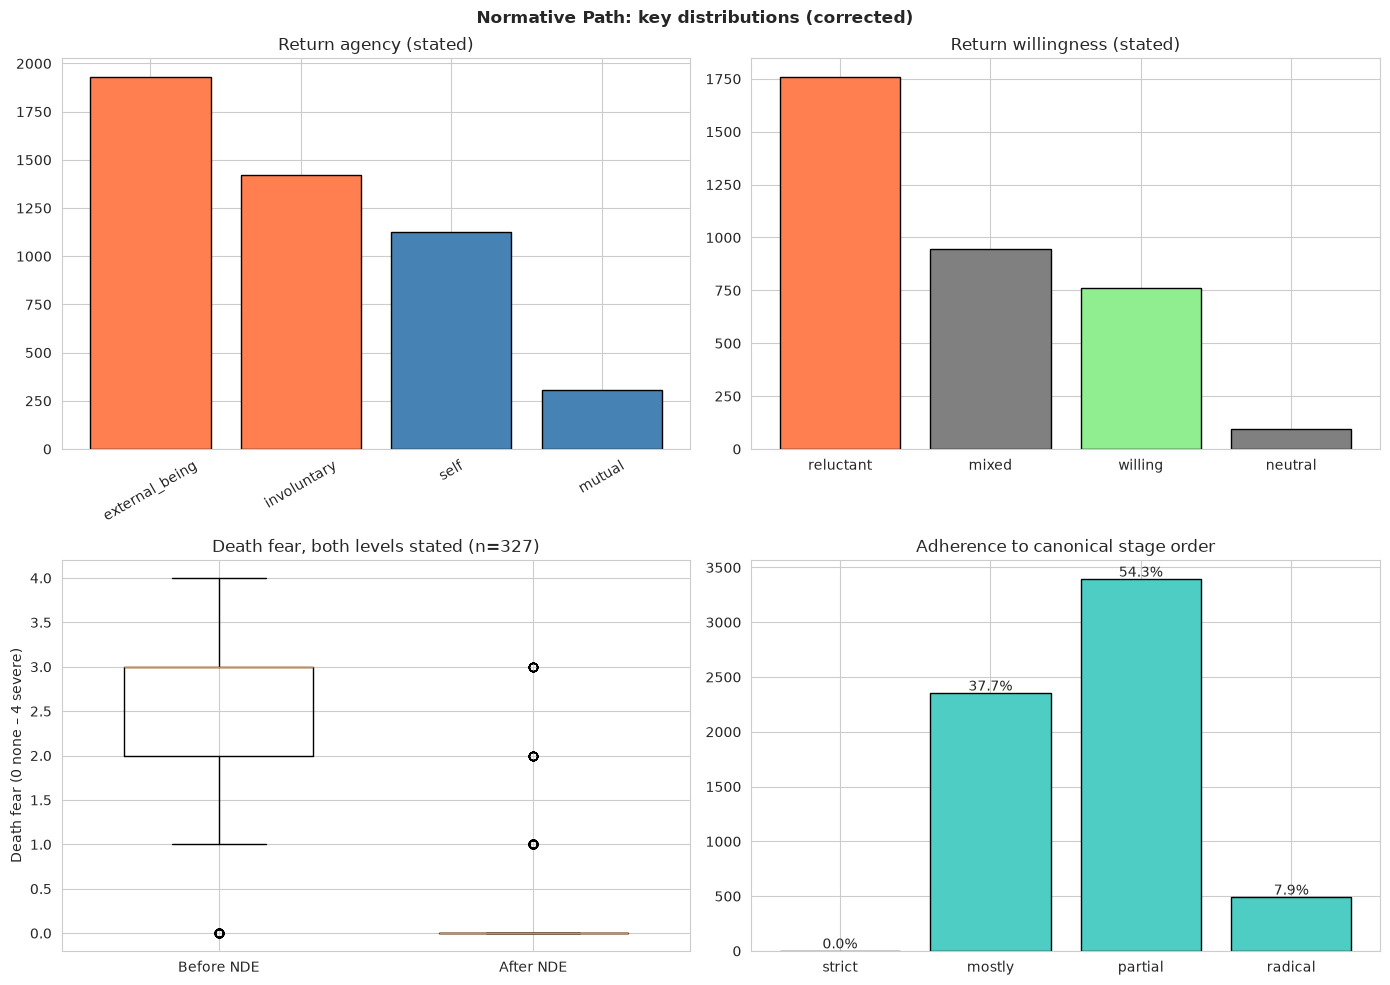

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
a = known["return_agency"].value_counts()
ax.bar(a.index, a.values, color=["coral" if k in ("external_being", "involuntary") else "steelblue" for k in a.index], edgecolor="black")
ax.set_title("Return agency (stated)"); ax.tick_params(axis="x", rotation=30)
ax = axes[0, 1]
w = wk["return_willingness"].value_counts()
ax.bar(w.index, w.values, color=["coral" if k == "reluctant" else "lightgreen" if k == "willing" else "gray" for k in w.index], edgecolor="black")
ax.set_title("Return willingness (stated)")
ax = axes[1, 0]
ax.boxplot([fear_x, fear_y], positions=[1, 2], widths=0.6)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Before NDE", "After NDE"]); ax.set_ylabel("Death fear (0 none – 4 severe)")
ax.set_title(f"Death fear, both levels stated (n={len(fear_x)})")
ax = axes[1, 1]
order = ["strict", "mostly", "partial", "radical"]
vals = [int((assess == k).sum()) for k in order]
ax.bar(order, vals, color="#4ECDC4", edgecolor="black")
for i, v in enumerate(vals):
    ax.text(i, v + 20, f"{100*v/len(assess):.1f}%", ha="center")
ax.set_title("Adherence to canonical stage order")
plt.suptitle("Normative Path: key distributions (corrected)", fontweight="bold")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "02_normative_path_summary.png", dpi=150, bbox_inches="tight"); plt.show()

---
# Conclusion: Normative path (corrected)

| Marker | Corrected result | Level of claim |
|---|---|---|
| Return agency | 70.1% of stated returns not self-chosen | Descriptive |
| Willingness | 49.4% reluctant, 21.4% willing (of stated) | Descriptive |
| Deceased relatives | 17.9% of NDEs | Consistent with continuation; **not a test** |
| Identity | Clear in 97.0% of accounts describing it | Supported, but not discriminating between models |
| Reincarnation content | Past-life 4.4%, intermission 1.0%, covenant 1.3%, chose mission 2.1% | Rarely reported; **not a test** of single-life path |
| Life review | 17.5% of NDEs; harsh 1.4%, uncomfortable 28.0%, loving 50.7% of rated | Non-condemning: supported; uniformly loving: not supported |
| Transformation | Fear ↓ 85% / ↑ 4%; spirituality ↑ 84%; religiosity unchanged (both levels stated) | Supported, reporting-selection caveat |
| Sequence | Strict canonical order ≈0%; mostly 37.7% | Fixed sequence **not supported** |

**Overall:** the data are *consistent with* a continuation model in several descriptive respects (valued state, encounters with the dead, preserved identity, rare reincarnation content, non-condemning review), but most of these markers do not discriminate between continuation and competing accounts, and the previous "5/5 markers support" verdict was produced by thresholds that could not fail. The one structural prediction that *could* fail — a characteristic sequence — is only weakly present.

---
**Notebook**: `02_normative_path_validation.ipynb` · **Schema Version**: 2026-01-06 · **Audited**: 2026-10-05